# 🛒 Shoplifting Detection
## Detección de Actividad Sospechosa con YOLOv8 Pose + XGBoost

**Pipeline:**
1. Extracción de keypoints del dataset con YOLOv8 Pose
2. Entrenamiento del clasificador XGBoost
3. Evaluación y visualización de resultados

In [9]:
import os
import cv2
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [ ]:
# ================================================================
#  CONFIGURACIÓN — ajusta las rutas si es necesario
# ================================================================

DATASET_PATH       = "dataset"
YOLO_MODEL_PATH    = "yolov8n-pose.pt"
CONFIDENCE_THRESH  = 0.50
NUM_KEYPOINTS      = 17
OUTPUT_CSV         = "keypoints_dataset.csv"
XGBOOST_MODEL_PATH = "models/xgboost_model.json"

# 0 = Normal  |  1 = Suspicious
CLASS_MAP = {0: "Normal", 1: "Suspicious"}

# Verificar que el dataset existe
for split in ["train", "test", "valid"]:
    path = Path(DATASET_PATH) / split / "images"
    status = "✅" if path.exists() else "❌"
    print(f"  {status}  {path}")

  ✅  dataset\train\images
  ✅  dataset\test\images
  ✅  dataset\valid\images


In [4]:
# ================================================================
#  FUNCIONES UTILITARIAS
# ================================================================

def read_yolo_class(label_path):
    """Lee la clase del primer objeto en un archivo de label YOLO."""
    try:
        with open(label_path) as f:
            first_line = f.readline().strip()
        if first_line:
            return int(first_line.split()[0])
    except Exception:
        pass
    return None


def keypoints_to_row(kps, class_id, img_name, split):
    """Convierte keypoints en una fila del CSV."""
    row = {"image": img_name, "split": split, "label": class_id}
    for j in range(NUM_KEYPOINTS):
        if j < len(kps):
            row[f"x{j}"] = round(kps[j][0], 6)
            row[f"y{j}"] = round(kps[j][1], 6)
        else:
            row[f"x{j}"] = 0.0
            row[f"y{j}"] = 0.0
    return row


def get_feature_columns():
    """Retorna los nombres de las columnas x0..x16, y0..y16."""
    return [f"x{j}" for j in range(NUM_KEYPOINTS)] + \
           [f"y{j}" for j in range(NUM_KEYPOINTS)]

print("✅ Funciones utilitarias definidas")

✅ Funciones utilitarias definidas


In [5]:
# ================================================================
#  CARGAR MODELO YOLOV8 POSE
# ================================================================

yolo_model = YOLO(YOLO_MODEL_PATH)

print(f"✅ Modelo cargado: {YOLO_MODEL_PATH}")

✅ Modelo cargado: yolov8n-pose.pt


In [10]:
# ================================================================
#  PASO 1: EXTRAER KEYPOINTS DEL DATASET
# ================================================================

all_rows = []
splits = ["train", "test", "valid"]

for split in splits:
    images_dir = Path(DATASET_PATH) / split / "images"
    labels_dir = Path(DATASET_PATH) / split / "labels"

    if not images_dir.exists():
        print(f"⚠ No se encontró: {images_dir} — se omite.")
        continue

    image_files = sorted(
        list(images_dir.glob("*.jpg")) +
        list(images_dir.glob("*.png")) +
        list(images_dir.glob("*.jpeg"))
    )

    normal_count = suspicious_count = skipped = 0
    print(f"\n📂 Procesando '{split}': {len(image_files)} imágenes")

    for img_path in tqdm(image_files, desc=f"  {split}"):
        label_path = labels_dir / (img_path.stem + ".txt")

        if not label_path.exists():
            skipped += 1
            continue

        class_id = read_yolo_class(label_path)
        if class_id is None:
            skipped += 1
            continue

        frame = cv2.imread(str(img_path))
        if frame is None:
            skipped += 1
            continue

        results = yolo_model(frame, verbose=False)

        for r in results:
            if r.keypoints is None or len(r.keypoints.xyn) == 0:
                continue

            kps_list = r.keypoints.xyn.tolist()
            confs    = r.boxes.conf.tolist() if r.boxes is not None else []

            if confs:
                best_idx = int(np.argmax(confs))
                if confs[best_idx] < CONFIDENCE_THRESH:
                    continue
            else:
                best_idx = 0

            row = keypoints_to_row(kps_list[best_idx], class_id,
                                   img_path.name, split)
            all_rows.append(row)

            if class_id == 0:
                normal_count += 1
            else:
                suspicious_count += 1
            break

    print(f"   ✅ Normal: {normal_count}  |  Suspicious: {suspicious_count}  |  Omitidas: {skipped}")

print("\n🏁 Extracción completada")


📂 Procesando 'train': 3317 imágenes


   ✅ Normal: 1220  |  Suspicious: 675  |  Omitidas: 852

📂 Procesando 'test': 896 imágenes










































































































































































































































































































































































































  test: 100%|██████████| 896/896 [00:28<00:00, 31.00it/s]


   ✅ Normal: 280  |  Suspicious: 272  |  Omitidas: 246

📂 Procesando 'valid': 512 imágenes








































































































































































































































































  valid: 100%|██████████| 512/512 [00:18<00:00, 27.45it/s]

   ✅ Normal: 166  |  Suspicious: 92  |  Omitidas: 84

🏁 Extracción completada


In [11]:
# ================================================================
#  GUARDAR KEYPOINTS EN CSV Y PREVIEW
# ================================================================

df = pd.DataFrame(all_rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ CSV guardado en: {OUTPUT_CSV}")
print(f"\n📊 Resumen del dataset:")
print(f"   Total muestras : {len(df)}")
print(f"   Normal (0)     : {len(df[df['label'] == 0])}")
print(f"   Suspicious (1) : {len(df[df['label'] == 1])}")
print(f"   Columnas       : {len(df.columns)}")

df.head()

✅ CSV guardado en: keypoints_dataset.csv

📊 Resumen del dataset:
   Total muestras : 2705
   Normal (0)     : 1666
   Suspicious (1) : 1011
   Columnas       : 37


,image,split,label,x0,y0,x1,y1,x2,y2,x3,...,x12,y12,x13,y13,x14,y14,x15,y15,x16,y16
0,Robbery087_x264_0_29.png,train,0,0.561362,0.135691,0.570838,0.110803,0.544029,0.116710,0.599793,...,0.517721,0.563676,0.632448,0.823296,0.547950,0.802048,0.621298,0.893026,0.626780,0.846364
1,Robbery087_x264_10_29.png,train,2,0.494990,0.456879,0.535620,0.427156,0.484092,0.408291,0.624439,...,0.433883,0.802845,0.518354,0.935088,0.369695,0.774936,0.461302,0.934732,0.469032,0.770991
2,Robbery087_x264_11_29.png,train,2,0.499707,0.384897,0.541059,0.350989,0.486431,0.336166,0.623014,...,0.456914,0.783645,0.556581,0.887728,0.322277,0.766937,0.514467,0.907455,0.370826,0.784457
3,Robbery087_x264_12_29.png,train,2,0.503563,0.347389,0.543789,0.317052,0.495116,0.304523,0.627957,...,0.450810,0.766152,0.533869,0.854740,0.305284,0.741140,0.491112,0.880377,0.367533,0.771178
4,Robbery087_x264_13_29.png,train,2,0.488104,0.330384,0.523918,0.301297,0.481239,0.290304,0.602432,...,0.499721,0.773020,0.565973,0.802267,0.317586,0.686589,0.545133,0.887847,0.367210,0.759733


In [12]:
# ================================================================
#  PASO 2: PREPARAR DATOS PARA ENTRENAMIENTO
# ================================================================

feat_cols = get_feature_columns()

train_df = df[df["split"] == "train"]
test_df  = df[df["split"].isin(["test", "valid"])]

X_train, y_train = train_df[feat_cols], train_df["label"]
X_test,  y_test  = test_df[feat_cols],  test_df["label"]

print(f"✅ Datos listos:")
print(f"   Entrenamiento : {len(X_train)} muestras")
print(f"   Evaluación    : {len(X_test)} muestras")
print(f"   Features      : {len(feat_cols)} columnas")

✅ Datos listos:
   Entrenamiento : 1895 muestras
   Evaluación    : 810 muestras
   Features      : 34 columnas


In [ ]:
# ================================================================
#  VERIFICAR CLASES EN EL DATASET
# ================================================================

print("Clases únicas en train:", sorted(y_train.unique()))
print("Clases únicas en test :", sorted(y_test.unique()))
print("\nDistribución en train:")
print(y_train.value_counts().sort_index())

Clases únicas en train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases únicas en test : [np.int64(0), np.int64(1), np.int64(3), np.int64(4)]

Distribución en train:
label
0    1220
1     649
2      14
3       5
4       7
Name: count, dtype: int64


In [15]:
# ================================================================
#  LIMPIAR: QUEDARSE SOLO CON CLASE 0 (Normal) y 1 (Suspicious)
# ================================================================

df_clean = df[df["label"].isin([0, 1])].reset_index(drop=True)

print(f"Muestras antes : {len(df)}")
print(f"Muestras después: {len(df_clean)}")
print(f"Descartadas     : {len(df) - len(df_clean)}")
print(f"\nDistribución final:")
print(f"   Normal (0)     : {len(df_clean[df_clean['label'] == 0])}")
print(f"   Suspicious (1) : {len(df_clean[df_clean['label'] == 1])}")

# Reemplazar splits con datos limpios
train_df = df_clean[df_clean["split"] == "train"]
test_df  = df_clean[df_clean["split"].isin(["test", "valid"])]

X_train, y_train = train_df[feat_cols], train_df["label"]
X_test,  y_test  = test_df[feat_cols],  test_df["label"]

print(f"\n✅ Listo para entrenar")
print(f"   Train: {len(X_train)}  |  Test: {len(X_test)}")

Muestras antes : 2705
Muestras después: 2677
Descartadas     : 28

Distribución final:
   Normal (0)     : 1666
   Suspicious (1) : 1011

✅ Listo para entrenar
   Train: 1869  |  Test: 808


In [16]:
# ================================================================
#  ENTRENAR CLASIFICADOR XGBOOST
# ================================================================

model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    eta=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print("✅ Entrenamiento completado")

✅ Entrenamiento completado


In [17]:
# ================================================================
#  EVALUACIÓN DEL MODELO
# ================================================================

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
acc         = accuracy_score(y_test, y_pred)
auc         = roc_auc_score(y_test, y_pred_prob)

print(f"✅ Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
print(f"   ROC-AUC  : {auc:.4f}")
print(f"\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred,
                            target_names=["Normal", "Suspicious"]))

✅ Accuracy : 0.5433  (54.3%)
   ROC-AUC  : 0.5233

📋 Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.56      0.86      0.67       446
  Suspicious       0.47      0.15      0.23       362

    accuracy                           0.54       808
   macro avg       0.51      0.51      0.45       808
weighted avg       0.52      0.54      0.48       808



In [18]:
# ================================================================
#  MEJORA 1: BALANCEAR CLASES
# ================================================================

# Calcular peso para compensar el desbalance Normal vs Suspicious
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"  Ratio Normal/Suspicious: {ratio:.2f} → scale_pos_weight={ratio:.2f}")

model_v2 = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    eta=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=ratio,
)

model_v2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

y_pred_v2      = model_v2.predict(X_test)
y_pred_prob_v2 = model_v2.predict_proba(X_test)[:, 1]
acc_v2         = accuracy_score(y_test, y_pred_v2)
auc_v2         = roc_auc_score(y_test, y_pred_prob_v2)

print(f"\n✅ Accuracy : {acc_v2:.4f}  ({acc_v2*100:.1f}%)")
print(f"   ROC-AUC  : {auc_v2:.4f}")
print(f"\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred_v2,
                            target_names=["Normal", "Suspicious"]))

  Ratio Normal/Suspicious: 1.88 → scale_pos_weight=1.88

✅ Accuracy : 0.5297  (53.0%)
   ROC-AUC  : 0.4797

📋 Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.55      0.78      0.65       446
  Suspicious       0.45      0.23      0.30       362

    accuracy                           0.53       808
   macro avg       0.50      0.50      0.47       808
weighted avg       0.51      0.53      0.49       808



In [19]:
# ================================================================
#  MEJORA 2: FEATURE ENGINEERING
#  - Coordenadas normalizadas al centro del cuerpo
#  - Distancias entre articulaciones clave
#  - Ángulos entre joints
# ================================================================

# Índices de keypoints YOLOv8
# 0:nariz  1:ojo_izq  2:ojo_der  3:oreja_izq  4:oreja_der
# 5:hombro_izq  6:hombro_der  7:codo_izq  8:codo_der
# 9:muñeca_izq  10:muñeca_der  11:cadera_izq  12:cadera_der
# 13:rodilla_izq  14:rodilla_der  15:tobillo_izq  16:tobillo_der

def calcular_distancia(p1x, p1y, p2x, p2y):
    return np.sqrt((p1x - p2x)**2 + (p1y - p2y)**2)

def calcular_angulo(p1x, p1y, p2x, p2y, p3x, p3y):
    """Ángulo en p2 formado por p1-p2-p3"""
    v1 = np.array([p1x - p2x, p1y - p2y])
    v2 = np.array([p3x - p2x, p3y - p2y])
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

def extract_features(df):
    rows = []

    for _, r in df.iterrows():
        x = [r[f"x{j}"] for j in range(17)]
        y = [r[f"y{j}"] for j in range(17)]

        # ── Centro del cuerpo (promedio caderas) ──────────────
        cx = (x[11] + x[12]) / 2
        cy = (y[11] + y[12]) / 2

        # ── Altura del torso para normalizar ──────────────────
        hombro_mid_y = (y[5] + y[6]) / 2
        torso_h = abs(cy - hombro_mid_y) + 1e-6

        # ── Coordenadas normalizadas ───────────────────────────
        xn = [(x[j] - cx) / torso_h for j in range(17)]
        yn = [(y[j] - cy) / torso_h for j in range(17)]

        # ── Distancias clave ───────────────────────────────────
        dists = {
            "d_muneca_izq_cadera" : calcular_distancia(x[9],  y[9],  x[11], y[11]),
            "d_muneca_der_cadera" : calcular_distancia(x[10], y[10], x[12], y[12]),
            "d_muneca_izq_hombro" : calcular_distancia(x[9],  y[9],  x[5],  y[5]),
            "d_muneca_der_hombro" : calcular_distancia(x[10], y[10], x[6],  y[6]),
            "d_munecas"           : calcular_distancia(x[9],  y[9],  x[10], y[10]),
            "d_codos"             : calcular_distancia(x[7],  y[7],  x[8],  y[8]),
            "d_hombros"           : calcular_distancia(x[5],  y[5],  x[6],  y[6]),
            "d_caderas"           : calcular_distancia(x[11], y[11], x[12], y[12]),
            "d_muneca_izq_rodilla": calcular_distancia(x[9],  y[9],  x[13], y[13]),
            "d_muneca_der_rodilla": calcular_distancia(x[10], y[10], x[14], y[14]),
        }

        # ── Ángulos clave ──────────────────────────────────────
        angles = {
            "ang_codo_izq"  : calcular_angulo(x[5], y[5], x[7], y[7], x[9],  y[9]),
            "ang_codo_der"  : calcular_angulo(x[6], y[6], x[8], y[8], x[10], y[10]),
            "ang_hombro_izq": calcular_angulo(x[7], y[7], x[5], y[5], x[11], y[11]),
            "ang_hombro_der": calcular_angulo(x[8], y[8], x[6], y[6], x[12], y[12]),
            "ang_rodilla_izq": calcular_angulo(x[11], y[11], x[13], y[13], x[15], y[15]),
            "ang_rodilla_der": calcular_angulo(x[12], y[12], x[14], y[14], x[16], y[16]),
            "ang_cadera_izq" : calcular_angulo(x[5],  y[5],  x[11], y[11], x[13], y[13]),
            "ang_cadera_der" : calcular_angulo(x[6],  y[6],  x[12], y[12], x[14], y[14]),
        }

        row = {}
        for j in range(17):
            row[f"xn{j}"] = xn[j]
            row[f"yn{j}"] = yn[j]
        row.update(dists)
        row.update(angles)
        row["label"] = r["label"]
        row["split"] = r["split"]
        rows.append(row)

    return pd.DataFrame(rows)

# Aplicar al dataset limpio
df_feat = extract_features(df_clean)

feat_cols_v2 = [c for c in df_feat.columns if c not in ["label", "split"]]

print(f"✅ Features generadas: {len(feat_cols_v2)} columnas")
print(f"   Coordenadas norm. : 34")
print(f"   Distancias        : 10")
print(f"   Ángulos           : 8")

✅ Features generadas: 52 columnas
   Coordenadas norm. : 34
   Distancias        : 10
   Ángulos           : 8


In [20]:
# ================================================================
#  REENTRENAR CON FEATURES MEJORADAS
# ================================================================

train_df2 = df_feat[df_feat["split"] == "train"]
test_df2  = df_feat[df_feat["split"].isin(["test", "valid"])]

X_train2, y_train2 = train_df2[feat_cols_v2], train_df2["label"]
X_test2,  y_test2  = test_df2[feat_cols_v2],  test_df2["label"]

ratio2 = len(y_train2[y_train2 == 0]) / len(y_train2[y_train2 == 1])

model_v3 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    eta=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    objective="binary:logistic",
    tree_method="hist",
    scale_pos_weight=ratio2,
    random_state=42,
)

model_v3.fit(
    X_train2, y_train2,
    eval_set=[(X_test2, y_test2)],
    verbose=False,
)

y_pred3      = model_v3.predict(X_test2)
y_pred_prob3 = model_v3.predict_proba(X_test2)[:, 1]
acc3         = accuracy_score(y_test2, y_pred3)
auc3         = roc_auc_score(y_test2, y_pred_prob3)

print(f"✅ Accuracy : {acc3:.4f}  ({acc3*100:.1f}%)")
print(f"   ROC-AUC  : {auc3:.4f}")
print(f"\n📋 Reporte de clasificación:")
print(classification_report(y_test2, y_pred3,
                            target_names=["Normal", "Suspicious"]))

✅ Accuracy : 0.4975  (49.8%)
   ROC-AUC  : 0.4457

📋 Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.54      0.67      0.59       446
  Suspicious       0.41      0.29      0.34       362

    accuracy                           0.50       808
   macro avg       0.47      0.48      0.47       808
weighted avg       0.48      0.50      0.48       808



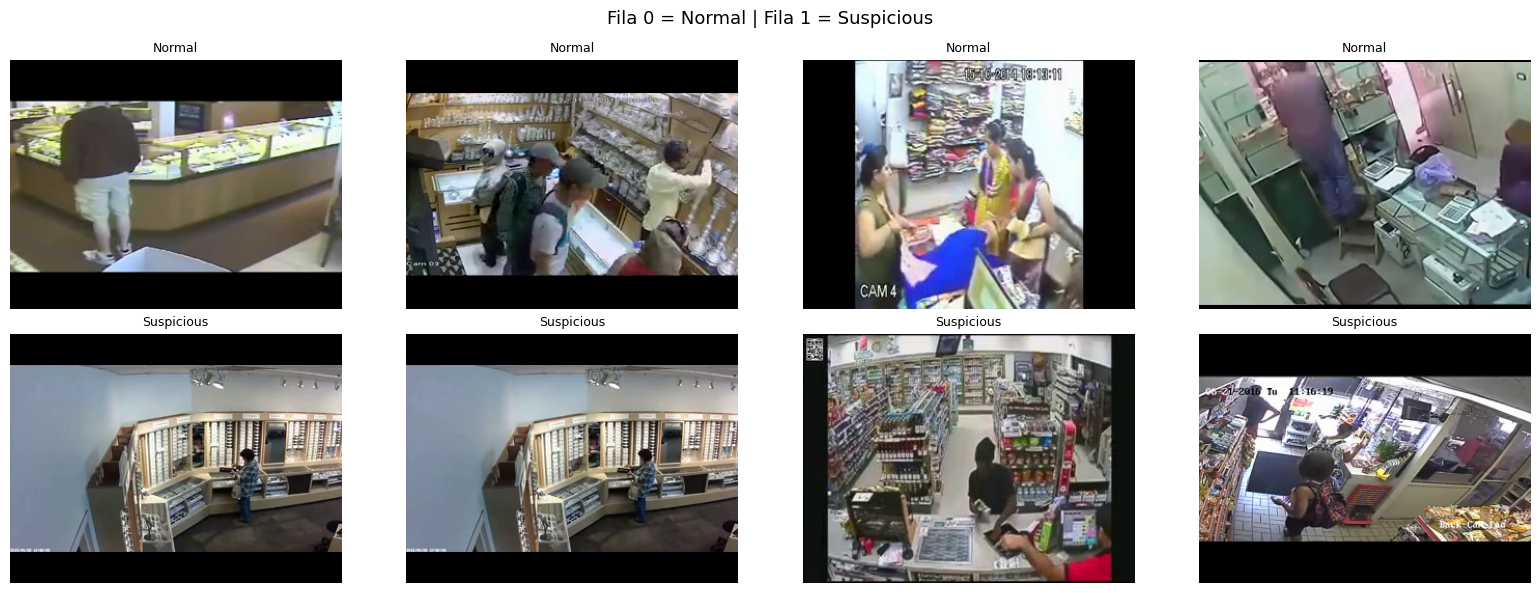


📊 Porcentaje de keypoints en cero por clase:
   Normal: 0.0% de valores en cero
   Suspicious: 0.0% de valores en cero


In [22]:
# ================================================================
#  DIAGNÓSTICO — Verificar imágenes y keypoints
# ================================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle("Fila 0 = Normal | Fila 1 = Suspicious", fontsize=13)

for row, (clase, nombre) in enumerate([(0, "Normal"), (1, "Suspicious")]):
    muestras = df_clean[df_clean["label"] == clase].sample(4, random_state=42)

    for col, (_, sample) in enumerate(muestras.iterrows()):
        split    = sample["split"]
        img_path = Path(DATASET_PATH) / split / "images" / sample["image"]
        img      = cv2.imread(str(img_path))

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row][col].imshow(img)
            axes[row][col].set_title(f"{nombre}", fontsize=9)
            axes[row][col].axis("off")

plt.tight_layout()
plt.show()

# Verificar calidad de keypoints
print("\n📊 Porcentaje de keypoints en cero por clase:")
for clase, nombre in [(0, "Normal"), (1, "Suspicious")]:
    subset = df_clean[df_clean["label"] == clase][feat_cols]
    zeros  = (subset == 0.0).mean().mean() * 100
    print(f"   {nombre}: {zeros:.1f}% de valores en cero")

In [23]:
# ================================================================
#  INVESTIGAR QUÉ SIGNIFICA CADA CLASE
# ================================================================

# Buscar archivo yaml o txt con nombres de clases
for ext in ["*.yaml", "*.yml", "*.txt", "*.names"]:
    archivos = list(Path(DATASET_PATH).glob(ext))
    if archivos:
        for f in archivos:
            print(f"📄 Encontrado: {f}")
            print(open(f).read())
            print("---")

# Ver nombres de archivos — a veces el nombre indica la clase
print("\n📁 Ejemplos de nombres de imágenes por clase:")
for clase in [0, 1, 2, 3, 4]:
    subset = df[df["label"] == clase].head(3)
    print(f"\n  Clase {clase}:")
    for _, row in subset.iterrows():
        print(f"    {row['image']}")


📁 Ejemplos de nombres de imágenes por clase:

  Clase 0:
    Robbery087_x264_0_29.png
    Robbery087_x264_17_29.png
    Robbery087_x264_18_29.png

  Clase 1:
    Robbery087_x264_3_29.png
    Robbery087_x264_8_29.png
    Robbery088_x264_12_29.png

  Clase 2:
    Robbery087_x264_10_29.png
    Robbery087_x264_11_29.png
    Robbery087_x264_12_29.png

  Clase 3:
    Robbery100_x264_12_58.png
    Robbery100_x264_25_58.png
    Robbery100_x264_9_58.png

  Clase 4:
    Robbery091_x264_9_29.png
    Robbery094_x264_0_29.png
    Robbery094_x264_0_58.png


In [24]:
# ================================================================
#  BUSCAR CONFIGURACIÓN DEL DATASET
# ================================================================

# Buscar en todas las subcarpetas
import os

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith((".yaml", ".yml", ".names", ".txt")):
            full_path = os.path.join(root, file)
            print(f"\n📄 {full_path}")
            print("-" * 40)
            print(open(full_path).read())

# También ver cuántas imágenes NO son Robbery
print("\n📊 Prefijos únicos en nombres de imágenes (train):")
prefijos = df[df["split"] == "train"]["image"].apply(
    lambda x: x.split("_")[0]
).value_counts()
print(prefijos)


📄 dataset\test\labels\Robbery010_x264_0_29.txt
----------------------------------------
0 0.321517 0.408138 0.107275 0.367448
0 0.707614 0.475339 0.139642 0.573366
0 0.375617 0.178175 0.132244 0.136868

📄 dataset\test\labels\Robbery010_x264_0_58.txt
----------------------------------------
0 0.331689 0.395191 0.157213 0.368681
0 0.700678 0.493835 0.157213 0.578298
0 0.387176 0.199137 0.099877 0.213317

📄 dataset\test\labels\Robbery010_x264_0_87.txt
----------------------------------------
0 0.331227 0.387176 0.148890 0.347719
0 0.685419 0.473490 0.143342 0.596794
0 0.390413 0.185573 0.130395 0.233046

📄 dataset\test\labels\Robbery010_x264_10_29.txt
----------------------------------------
0 0.314118 0.377312 0.146116 0.384710
0 0.715937 0.483970 0.135943 0.622688
0 0.383940 0.199137 0.102651 0.196054

📄 dataset\test\labels\Robbery010_x264_10_58.txt
----------------------------------------
0 0.321979 0.391492 0.124846 0.373613
0 0.751541 0.485203 0.162762 0.644883
0 0.377928 0.223798 0

In [25]:
# ¿Qué ves tú en las imágenes de clase 0 vs clase 1?
# Según los labels del dataset de Sparsh Goyal:
#   Clase 0 = persona con comportamiento NORMAL dentro del video
#   Clase 1 = persona con comportamiento SOSPECHOSO (robando)
# El problema: ambas clases están en el MISMO video de crimen,
# por eso las poses son muy similares.

print("Distribución por prefijo de video y clase:")
df_clean["prefijo"] = df_clean["image"].apply(lambda x: x.split("_")[0])
print(df_clean.groupby(["prefijo", "label"]).size().unstack(fill_value=0).head(10))

Distribución por prefijo de video y clase:
label        0   1
prefijo           
Robbery001  14   5
Robbery002  16  19
Robbery003  13  12
Robbery004  12  13
Robbery006  15  28
Robbery007  25   2
Robbery008  38  10
Robbery009  33   2
Robbery010  70   1
Robbery013   0  58


In [26]:
print("Labels en df_feat:")
print(df_feat["label"].value_counts())
print()
print("¿Son los mismos que df_clean?")
print(f"df_clean: {len(df_clean)} filas")
print(f"df_feat:  {len(df_feat)} filas")
print()
# Ver ejemplos de clase 0 vs 1 por video
print("Clase 0 vs 1 por prefijo (primeros 5):")
df_feat["prefijo"] = df_clean["prefijo"].values
print(df_feat.groupby(["prefijo","label"]).size().unstack(fill_value=0).head(5))

Labels en df_feat:
label
0    1666
1    1011
Name: count, dtype: int64

¿Son los mismos que df_clean?
df_clean: 2677 filas
df_feat:  2677 filas

Clase 0 vs 1 por prefijo (primeros 5):
label        0   1
prefijo           
Robbery001  14   5
Robbery002  16  19
Robbery003  13  12
Robbery004  12  13
Robbery006  15  28


In [27]:
# ================================================================
#  REENTRENAR LIMPIO — verificar que df_feat esté bien
# ================================================================

train_df2 = df_feat[df_feat["split"] == "train"].drop(columns=["prefijo"], errors="ignore")
test_df2  = df_feat[df_feat["split"].isin(["test", "valid"])].drop(columns=["prefijo"], errors="ignore")

X_train2 = train_df2[feat_cols_v2]
y_train2 = train_df2["label"]
X_test2  = test_df2[feat_cols_v2]
y_test2  = test_df2["label"]

print(f"Train: {len(X_train2)} | Test: {len(X_test2)}")
print(f"Features: {len(feat_cols_v2)}")
print(f"NaN en features: {X_train2.isna().sum().sum()}")

Train: 1869 | Test: 808
Features: 52
NaN en features: 0


In [28]:
ratio2 = len(y_train2[y_train2 == 0]) / len(y_train2[y_train2 == 1])
print(f"Ratio: {ratio2:.2f}")

model_v3 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    eta=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    eval_metric="logloss",
    objective="binary:logistic",
    tree_method="hist",
    scale_pos_weight=ratio2,
    random_state=42,
)

model_v3.fit(X_train2, y_train2,
             eval_set=[(X_test2, y_test2)],
             verbose=False)

y_pred3      = model_v3.predict(X_test2)
y_pred_prob3 = model_v3.predict_proba(X_test2)[:, 1]
acc3  = accuracy_score(y_test2, y_pred3)
auc3  = roc_auc_score(y_test2, y_pred_prob3)

print(f"\n✅ Accuracy : {acc3:.4f}  ({acc3*100:.1f}%)")
print(f"   ROC-AUC  : {auc3:.4f}")
print(classification_report(y_test2, y_pred3,
                            target_names=["Normal","Suspicious"]))

Ratio: 1.88

✅ Accuracy : 0.5037  (50.4%)
   ROC-AUC  : 0.4533
              precision    recall  f1-score   support

      Normal       0.54      0.72      0.61       446
  Suspicious       0.41      0.24      0.31       362

    accuracy                           0.50       808
   macro avg       0.47      0.48      0.46       808
weighted avg       0.48      0.50      0.48       808

